In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
fake = Faker()
random.seed(42)

num_bookings = 200

data = {
    'booking_id': range(1, num_bookings + 1),
    'client_name': [fake.name() for _ in range(num_bookings)],
    'date': [fake.date_between(start_date='-6m', end_date='today') for _ in range(num_bookings)],
    'group_size': [random.randint(1, 8) for _ in range(num_bookings)],
    'duration_hours': [random.choice([1, 2, 3, 4]) for _ in range(num_bookings)],
    'service_type': [random.choice(['Private Spa', 'Birthday Party', 'Couples Session', 'Group Session']) for _ in range(num_bookings)],
    'fnb_order': [random.choice(['Pizza', 'Coffee', 'Coca Cola', 'Champagne', 'None']) for _ in range(num_bookings)],
    'towels_used': [random.randint(2, 10) for _ in range(num_bookings)],
    'revenue_eur': [random.randint(80, 500) for _ in range(num_bookings)],
}

df = pd.DataFrame(data)
print(df.head(10))

   booking_id          client_name        date  group_size  duration_hours  \
0           1  Dr. Stephanie Patel  2026-05-04           2               1   
1           2         Ashley Davis  2026-05-04           1               1   
2           3           Jon Larson  2026-05-04           5               1   
3           4      Amanda Thompson  2026-05-04           4               2   
4           5       Carrie Perkins  2026-05-04           4               2   
5           6       Stephen Conner  2026-05-04           3               4   
6           7      Timothy Edwards  2026-05-04           2               4   
7           8        Jared Bentley  2026-05-04           2               4   
8           9         James Cooley  2026-05-04           7               2   
9          10        Autumn Garcia  2026-05-04           1               4   

      service_type  fnb_order  towels_used  revenue_eur  
0      Private Spa      Pizza            5          152  
1  Couples Session  Coca 

In [4]:
df.to_csv('myspa_data.csv', index=False)
print("Data saved successfully!")


Data saved successfully!


In [5]:
print("Total Bookings:", len(df))
print("Total Revenue: €", df['revenue_eur'].sum())
print("Average Revenue per Booking: €", round(df['revenue_eur'].mean(), 2))
print("Most Popular Service:", df['service_type'].value_counts().index[0])
print("Most Popular F&B Item:", df['fnb_order'].value_counts().index[0])

Total Bookings: 200
Total Revenue: € 57242
Average Revenue per Booking: € 286.21
Most Popular Service: Group Session
Most Popular F&B Item: Coca Cola


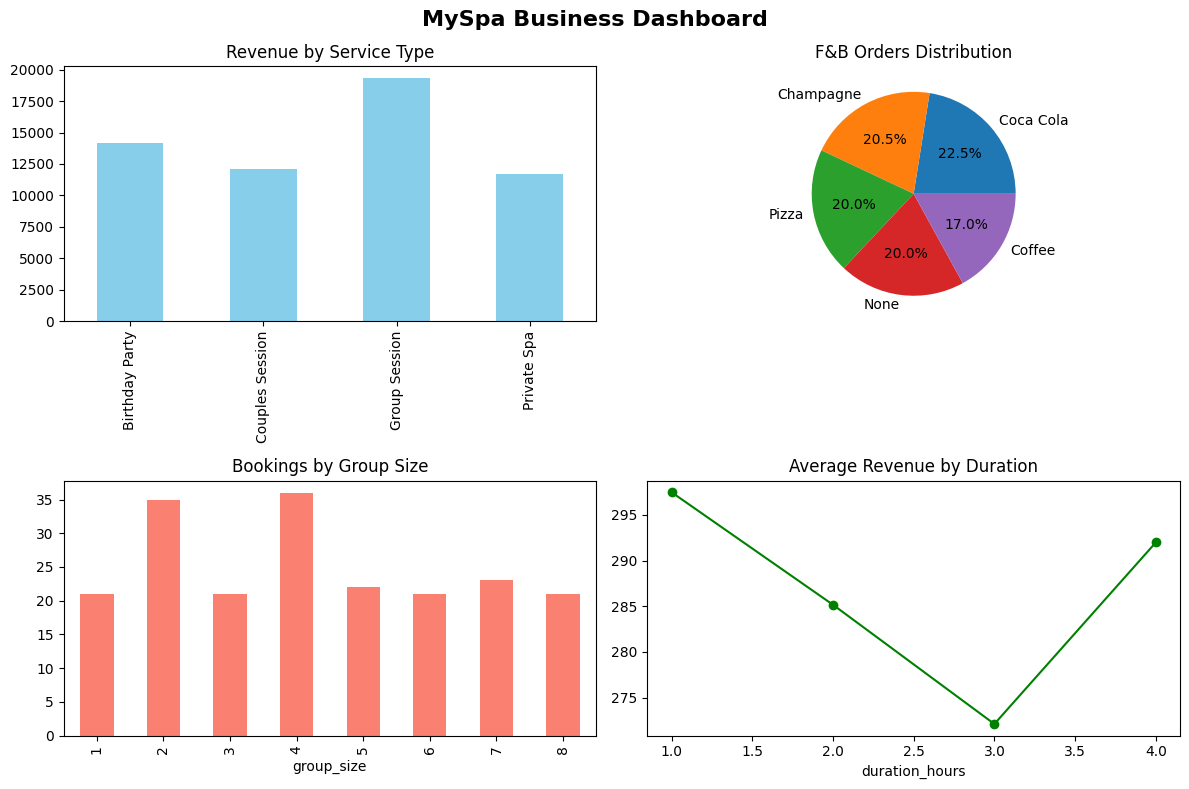

Dashboard saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('MySpa Business Dashboard', fontsize=16, fontweight='bold')

# Chart 1 - Revenue by Service Type
df.groupby('service_type')['revenue_eur'].sum().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Revenue by Service Type')
axes[0,0].set_xlabel('')

# Chart 2 - Popular F&B Items
df['fnb_order'].value_counts().plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%')
axes[0,1].set_title('F&B Orders Distribution')

# Chart 3 - Bookings by Group Size
df['group_size'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='salmon')
axes[1,0].set_title('Bookings by Group Size')

# Chart 4 - Revenue by Duration
df.groupby('duration_hours')['revenue_eur'].mean().plot(kind='line', ax=axes[1,1], marker='o', color='green')
axes[1,1].set_title('Average Revenue by Duration')

plt.tight_layout()
plt.savefig('myspa_dashboard.png')
plt.show()
print("Dashboard saved!")
